In [43]:
import pandas as pd
from sklearn.impute import SimpleImputer
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from itertools import combinations, product
from sklearn.base import clone, BaseEstimator, ClassifierMixin
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
import scipy
import matplotlib.patheffects as PathEffects
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline, _name_estimators, Pipeline
import operator
from sklearn.model_selection import StratifiedKFold, train_test_split, learning_curve, validation_curve, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.utils import resample
from sklearn.metrics import confusion_matrix, precision_score, matthews_corrcoef, recall_score, f1_score, make_scorer, roc_curve, roc_auc_score, auc
from scipy.special import comb
import math

In [44]:
def ensemble_error(n_classifier, error):
    k_start = int(math.ceil(n_classifier/ 2.))
    probs = [comb(n_classifier, k) * error**k * (1 - error)**(n_classifier - k) for k in range(k_start, n_classifier + 1)]
    return sum(probs)
ensemble_error(n_classifier=11, error=0.25)

np.float64(0.03432750701904297)

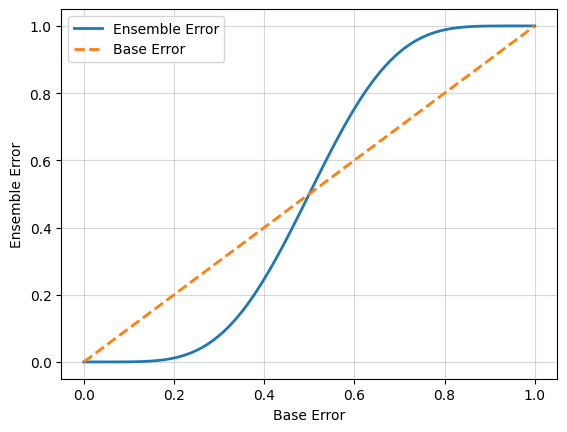

In [45]:
error_range = np.arange(0.0, 1.01, 0.01)
ens_error = [ensemble_error(n_classifier=11, error=error) for error in error_range]
plt.plot(error_range, ens_error, label='Ensemble Error', linewidth=2)
plt.plot(error_range, error_range,linestyle='--' ,label='Base Error', linewidth=2)
plt.ylabel('Ensemble Error')
plt.xlabel('Base Error')
plt.legend(loc='upper left')
plt.grid(alpha=0.5)
plt.show()

In [46]:
np.argmax(np.bincount([0,0,1, 0] , weights=[0.2, 0.2, 0.4, 0.2]))

np.int64(0)

In [47]:
ex = np.array([[0.3, 0.7],
               [0.35,0.65],
               [0.15, 0.85]])
p = np.average(ex, axis=0, weights=[0.2, 0.3, 0.5])
np.argmax(p)

np.int64(1)

In [48]:
class MajorityVoteClassifier(ClassifierMixin, BaseEstimator):
    def __init__(self, classifiers, vote='classlabel', weights=None):
        self.classifiers = classifiers
        self.named_classifiers = {
            key: value for key, value in _name_estimators(classifiers)
        }
        self.vote = vote
        self.weights = weights
    def fit(self, X, y):
        if self.vote not in ('probability', 'classlabel'):
            raise ValueError(f"vote must be 'probability' "
            f"or 'classlabel'"
            f"; got (vote={self.vote})")
        if self.weights and len(self.weights) != len(self.classifiers):
            raise ValueError(f'Number of classifiers and'
            f' weights must be equal'
            f'; got {len(self.weights)} weights,'
            f' {len(self.classifiers)} classifiers')
        # Use LabelEncoder to ensure class labels start
        # with 0, which is important for np.argmax
        # call in self.predict
        self.lablenc_ = LabelEncoder()
        self.lablenc_.fit(y)
        self.classes_ = self.lablenc_.classes_
        self.classifiers_ = []
        for clf in self.classifiers:
            fitted_clf = clone(clf).fit(X,
            self.lablenc_.transform(y))
            self.classifiers_.append(fitted_clf)
        return self
    def predict(self, X):
        if self.vote == 'probability':
            maj_vote = np.argmax(self.predict_proba(X), axis=1)
        else:
            predictions = np.asarray([
            clf.predict(X) for clf in self.classifiers_
            ]).T
            maj_vote = np.apply_along_axis(
            lambda x: np.argmax(
            np.bincount(x, weights=self.weights)
            ),
            axis=1, arr=predictions
            )
            maj_vote = self.lablenc_.inverse_transform(maj_vote)
            return maj_vote
    def predict_proba(self, X):
        probas = np.asarray([clf.predict_proba(X)
        for clf in self.classifiers_])
        avg_proba = np.average(probas, axis=0,
        weights=self.weights)
        return avg_proba
    def get_params(self, deep=True):
        if not deep:
            return super().get_params(deep=False)
        else:
            out = self.named_classifiers.copy()
        for name, step in self.named_classifiers.items():
            for key, value in step.get_params(
                deep=True).items():
                out[f'{name}__{key}'] = value
        return out

In [49]:
iris = datasets.load_iris()
X, y = iris.data[50:, [1, 2]], iris.target[50:]
le = LabelEncoder()
y = le.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=1, stratify=y)
clf1 = LogisticRegression(penalty='l2', solver='lbfgs', C=0.001, random_state=1)
clf2 = DecisionTreeClassifier(max_depth=1, criterion='entropy', random_state=0)
clf3 = KNeighborsClassifier(n_neighbors=1, p=2, metric='minkowski')

pipe1 = Pipeline([['sc',StandardScaler()], ['clf',clf1]])
pipe3 = Pipeline([['sc',StandardScaler()], ['clf' ,clf3]])
clf_labels = ['LogisticRegression', 'DecisionTreeClassifier', 'KNeighborsClassifier']
print('10 k-fold validation')
for clf, label in zip([pipe1, clf2, pipe3], clf_labels):
    scores = cross_val_score(estimator=clf, X=X_train, y=y_train, cv=10, scoring='roc_auc')
    print(f'ROC AUC: {scores.mean():0.2f}'
          f'(+/-) {scores.std():0.2f} [{label}]')
    

10 k-fold validation
ROC AUC: 0.92(+/-) 0.15 [LogisticRegression]
ROC AUC: 0.87(+/-) 0.18 [DecisionTreeClassifier]
ROC AUC: 0.85(+/-) 0.13 [KNeighborsClassifier]


In [50]:
mv_clf = MajorityVoteClassifier(classifiers=[pipe1, clf2, pipe3])
clf_labels += ['Majority Class']
all_clf = [pipe1, clf2, pipe3, mv_clf]
for clf, label in zip(all_clf, clf_labels):
    scores = cross_val_score(estimator=clf, X=X_train, y=y_train, cv=10, scoring='roc_auc')
    print(f'ROC AUC: {scores.mean():0.2f}'
        f'(+/-) {scores.std():0.2f} [{label}]')

ROC AUC: 0.92(+/-) 0.15 [LogisticRegression]
ROC AUC: 0.87(+/-) 0.18 [DecisionTreeClassifier]
ROC AUC: 0.85(+/-) 0.13 [KNeighborsClassifier]
ROC AUC: 0.98(+/-) 0.05 [Majority Class]


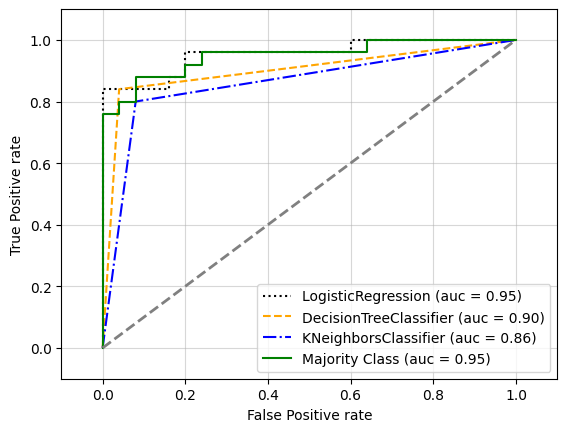

In [51]:
colors = ['black', 'orange', 'blue', 'green']
linestyle = [':', '--', '-.', '-']
for clf, label, clr, ls in zip(all_clf, clf_labels, colors, linestyle):
    y_pred = clf.fit(X_train, y_train).predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_true=y_test, y_score=y_pred)
    roc_auc = auc(x=fpr, y=tpr)
    plt.plot(fpr, tpr, color=clr, linestyle=ls, label=f'{label} (auc = {roc_auc:.2f})')
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=2)
plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1])
plt.grid(alpha=0.5)
plt.xlabel('False Positive rate')
plt.ylabel('True Positive rate')
plt.show()

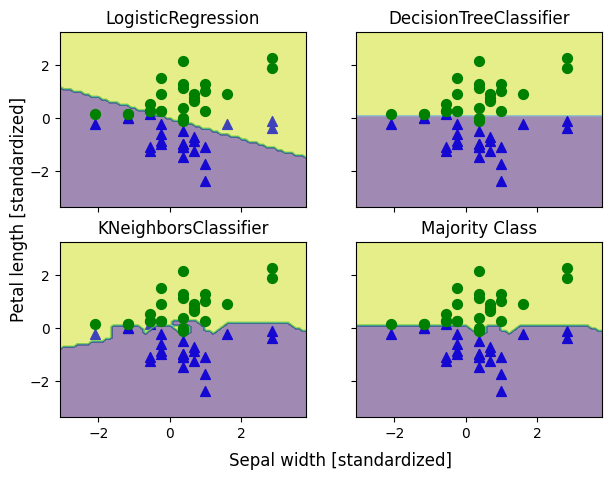

In [52]:
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
x_min = X_train_std[:, 0].min() - 1
x_max = X_train_std[:, 0].max() + 1
y_min = X_train_std[:, 1].min() - 1
y_max = X_train_std[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                        np.arange(y_min, y_max, 0.1))
f, axarr = plt.subplots(nrows=2, ncols=2, sharex='col', sharey='row', figsize=(7, 5))
for idx, clf, tt in zip(product([0, 1], [0, 1]), all_clf, clf_labels):
    clf.fit(X_train_std, y_train)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    axarr[idx[0], idx[1]].contourf(xx, yy, Z, alpha=0.3)
    axarr[idx[0], idx[1]].scatter(X_train_std[y_train == 1, 0], X_train_std[y_train == 0, 1], c='blue', marker='^', s=50)
    axarr[idx[0], idx[1]].contourf(xx, yy, Z, alpha=0.3)
    axarr[idx[0], idx[1]].scatter(X_train_std[y_train == 1, 0], X_train_std[y_train == 1, 1], c='green', marker='o', s=50)
    axarr[idx[0], idx[1]].set_title(tt)
plt.text(-3.5, -5., s='Sepal width [standardized]', ha='center', va='center', fontsize=12)
plt.text(-12.5, 4.5, s='Petal length [standardized]',  ha='center', va='center', fontsize=12, rotation=90)
plt.show()


In [53]:
param = {'decisiontreeclassifier__max_depth': [1, 2],
         'pipeline-1__clf__C': [0.001, 0.1, 100.0]}
grid = GridSearchCV(estimator=mv_clf, param_grid=param, cv=10, scoring='roc_auc')
grid.fit(X_train, y_train)

,estimator,MajorityVoteC...ghbors=1)]])])
,param_grid,"{'decisiontreeclassifier__max_depth': [1, 2], 'pipeline-1__clf__C': [0.001, 0.1, ...]}"
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,pipeline-1,Pipeline(step...om_state=1)]])


In [54]:
for r, _ in enumerate(grid.cv_results_['mean_test_score']):
    mean_score = grid.cv_results_['mean_test_score'][r]
    std_dev = grid.cv_results_['std_test_score'][r]
    params = grid.cv_results_['params'][r]
    print(f'{mean_score:.3f} +/- {std_dev:.2f} {params}')

0.983 +/- 0.05 {'decisiontreeclassifier__max_depth': 1, 'pipeline-1__clf__C': 0.001}
0.983 +/- 0.05 {'decisiontreeclassifier__max_depth': 1, 'pipeline-1__clf__C': 0.1}
0.967 +/- 0.10 {'decisiontreeclassifier__max_depth': 1, 'pipeline-1__clf__C': 100.0}
0.983 +/- 0.05 {'decisiontreeclassifier__max_depth': 2, 'pipeline-1__clf__C': 0.001}
0.983 +/- 0.05 {'decisiontreeclassifier__max_depth': 2, 'pipeline-1__clf__C': 0.1}
0.967 +/- 0.10 {'decisiontreeclassifier__max_depth': 2, 'pipeline-1__clf__C': 100.0}


In [55]:
print(f'Best parameters: {grid.best_params_}')

Best parameters: {'decisiontreeclassifier__max_depth': 1, 'pipeline-1__clf__C': 0.001}


In [56]:
print(f'ROC AUC : {grid.best_score_:.2f}')

ROC AUC : 0.98


In [57]:
df_wine = pd.read_csv('https://archive.ics.uci.edu/ml/'
                        'machine-learning-databases/'
                        'wine/wine.data',
                        header=None)
df_wine.columns = ['Class label', 'Alcohol',
                    'Malic acid', 'Ash',
                    'Alcalinity of ash',
                    'Magnesium', 'Total phenols',
                    'Flavanoids', 'Nonflavanoid phenols',
                    'Proanthocyanins',
                    'Color intensity', 'Hue',
                    'OD280/OD315 of diluted wines',
                    'Proline']
df_wine = df_wine[df_wine['Class label'] != 1]
y = df_wine['Class label'].values
X = df_wine[['Alcohol', 'OD280/OD315 of diluted wines']].values

In [58]:
le = LabelEncoder()
y = le.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

In [59]:
tree = DecisionTreeClassifier(criterion='entropy', random_state=1, max_depth=None)
bag = BaggingClassifier(estimator=tree, n_estimators=500, max_features=1.0, max_samples=1.0, bootstrap=True, n_jobs=None, bootstrap_features=False, random_state=1)
tree = tree.fit(X_train, y_train)
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)
train_tree = f1_score(y_train, y_train_pred)
test_tree = f1_score(y_test, y_test_pred)
print(f'Decision tree train/test accuracies '
    f'{train_tree:.3f}/{test_tree:.3f}')
coffmax = confusion_matrix(y_true=y_test, y_pred=y_test_pred)
coffmax2 = confusion_matrix(y_true=y_train, y_pred=y_train_pred)
print(coffmax)
print(coffmax2)

Decision tree train/test accuracies 1.000/0.800
[[12  2]
 [ 2  8]]
[[57  0]
 [ 0 38]]


In [60]:
bag = bag.fit(X_train, y_train)
y_train_pred = bag.predict(X_train)
y_test_pred = bag.predict(X_test)
train_bag = f1_score(y_train, y_train_pred)
test_bag = f1_score(y_test, y_test_pred)
print(f'Decision bag train/test accuracies '
    f'{train_bag:.3f}/{test_bag:.3f}')
coffmax = confusion_matrix(y_true=y_test, y_pred=y_test_pred)
coffmax2 = confusion_matrix(y_true=y_train, y_pred=y_train_pred)
print(coffmax)
print(coffmax2)

Decision bag train/test accuracies 1.000/0.909
[[12  2]
 [ 0 10]]
[[57  0]
 [ 0 38]]


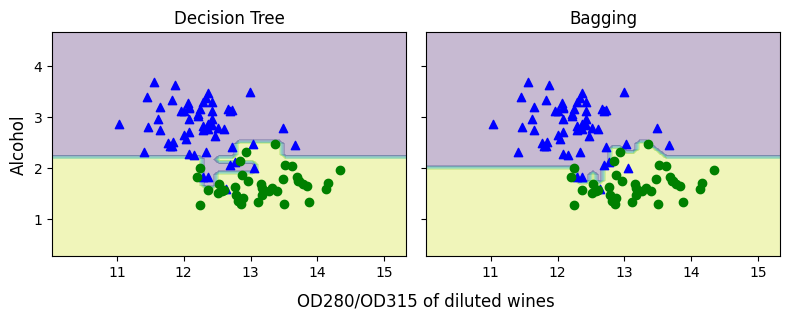

In [61]:
x_min = X_train[:, 0].min() - 1
x_max = X_train[:, 0].max() + 1
y_min = X_train[:, 1].min() - 1
y_max = X_train[:, 1].max() + 1
xx , yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
f, axarr = plt.subplots(nrows=1, ncols=2, sharex='col', sharey='row', figsize=(8, 3))
for idx, clf, tt in zip([0, 1], [tree, bag], ['Decision Tree', 'Bagging']):
    clf.fit(X_train, y_train)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    axarr[idx].contourf(xx, yy, Z, alpha=0.3)
    axarr[idx].scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c='blue', marker='^')
    axarr[idx].scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c='green', marker='o')
    axarr[idx].set_title(tt)
axarr[0].set_ylabel('Alcohol', fontsize=12)
plt.tight_layout()
plt.text(0, -0.2, s='OD280/OD315 of diluted wines', ha='center', va='center', fontsize=12, transform=axarr[1].transAxes)
plt.show()


In [62]:
y = np.array([1, 1, 1, -1, -1, -1, 1, 1, 1, -1])
yhat = np.array([1, 1, 1, -1, -1, -1, -1, -1, -1, -1])
correct = (y == yhat)
weights = np.full(10, 0.1)
epsilon = np.mean(~correct)
print(epsilon)

0.3


In [63]:
alpha_j = 0.5 * np.log((1-epsilon) / epsilon)
print(alpha_j)

0.42364893019360184


In [64]:
update_weights_correct = 0.1 * np.exp(-alpha_j * 1 * 1)
print(update_weights_correct)

0.06546536707079771


In [65]:
update_weights_wrong = 0.1 * np.exp(-alpha_j * 1 * -1)
print(update_weights_wrong)

0.1527525231651947


In [66]:
weights = np.where(correct == 1, update_weights_correct, update_weights_wrong)
print(weights)

[0.06546537 0.06546537 0.06546537 0.06546537 0.06546537 0.06546537
 0.15275252 0.15275252 0.15275252 0.06546537]


In [67]:
normalized_weights = weights / np.sum(weights)
normalized_weights

array([0.07142857, 0.07142857, 0.07142857, 0.07142857, 0.07142857,
       0.07142857, 0.16666667, 0.16666667, 0.16666667, 0.07142857])

In [68]:
tree = DecisionTreeClassifier(criterion='entropy', random_state=1, max_depth=1)
ada = AdaBoostClassifier(estimator=tree,n_estimators=500,learning_rate=0.1,random_state=1)
tree = tree.fit(X_train, y_train)
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)
train_tree = f1_score(y_train, y_train_pred)
test_tree = f1_score(y_test, y_test_pred)
print(f'Decision tree train/test accuracies '
    f'{train_tree:.3f}/{test_tree:.3f}')
coffmax = confusion_matrix(y_true=y_test, y_pred=y_test_pred)
coffmax2 = confusion_matrix(y_true=y_train, y_pred=y_train_pred)
print(coffmax)
print(coffmax2)

Decision tree train/test accuracies 0.900/0.870
[[11  3]
 [ 0 10]]
[[51  6]
 [ 2 36]]


In [69]:
ada = ada.fit(X_train, y_train)
y_train_pred = ada.predict(X_train)
y_test_pred = ada.predict(X_test)
train_ada = f1_score(y_train, y_train_pred)
test_ada = f1_score(y_test, y_test_pred)
print(f'Decision ada train/test accuracies '
    f'{train_tree:.3f}/{test_tree:.3f}')
coffmax = confusion_matrix(y_true=y_test, y_pred=y_test_pred)
coffmax2 = confusion_matrix(y_true=y_train, y_pred=y_train_pred)
print(coffmax)
print(coffmax2)

Decision ada train/test accuracies 0.900/0.870
[[12  2]
 [ 0 10]]
[[54  3]
 [ 0 38]]


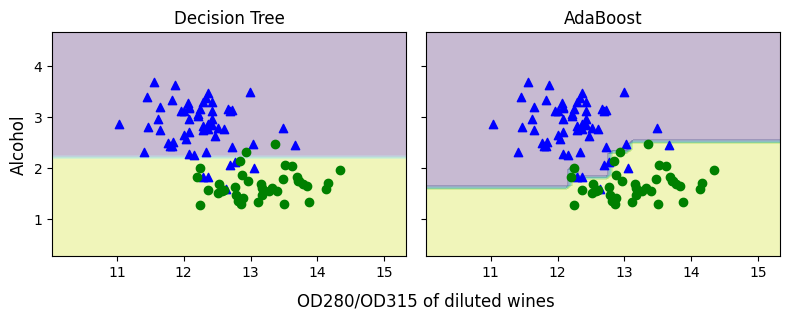

In [70]:
x_min = X_train[:, 0].min() - 1
x_max = X_train[:, 0].max() + 1
y_min = X_train[:, 1].min() - 1
y_max = X_train[:, 1].max() + 1
xx , yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
f, axarr = plt.subplots(nrows=1, ncols=2, sharex='col', sharey='row', figsize=(8, 3))
for idx, clf, tt in zip([0, 1], [tree, ada], ['Decision Tree', 'AdaBoost']):
    clf.fit(X_train, y_train)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    axarr[idx].contourf(xx, yy, Z, alpha=0.3)
    axarr[idx].scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c='blue', marker='^')
    axarr[idx].scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c='green', marker='o')
    axarr[idx].set_title(tt)
axarr[0].set_ylabel('Alcohol', fontsize=12)
plt.tight_layout()
plt.text(0, -0.2, s='OD280/OD315 of diluted wines', ha='center', va='center', fontsize=12, transform=axarr[1].transAxes)
plt.show()
